In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.21


Found existing installation: mediapipe 0.10.21
Uninstalling mediapipe-0.10.21:
  Successfully uninstalled mediapipe-0.10.21
  Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl (35.6 MB)


In [ ]:
import mediapipe as mp
import cv2
print(mp.__version__)
print(cv2.__version__)

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


0.10.21
4.11.0


In [ ]:
mp_drawing=mp.solutions.drawing_utils
mp_face_mesh=mp.solutions.face_mesh
mp_drawing_styles=mp.solutions.drawing_styles
draw_specs=mp_drawing.DrawingSpec(thickness=1,circle_radius=1,color=(0,255,0))

In [ ]:
def get_landmark(image):
  face_mesh=mp_face_mesh.FaceMesh(static_image_mode=True,max_num_faces=1,
            refine_landmarks=True,min_detection_confidence=0.5)
  image.flags.writeable=False
  result=face_mesh.process(image)

  landmark=result.multi_face_landmarks[0].landmark
  return result,landmark

In [ ]:
def draw_landmarks(image,result):
  image.flags.writeable=True
  if result.multi_face_landmarks:
    for face_landmarks in result.multi_face_landmarks:
      mp_drawing.draw_landmarks(image=image,
                                connections=mp_face_mesh.FACEMESH_TESSELATION,
                                landmark_list=face_landmarks,
                                landmark_drawing_spec=None,
                                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style())
      # mp_drawing.draw_landmarks(image=image,
      #                           landmark_list=face_landmarks,
      #                           connections=mp_face_mesh.FACEMESH_CONTOURS,
      #                           landmark_drawing_spec=None,
      #                           connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style())
      mp_drawing.draw_landmarks(image=image,
                                landmark_list=face_landmarks,
                                connections=mp_face_mesh.FACEMESH_IRISES,
                                landmark_drawing_spec=None,
                                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_iris_connections_style())
  result.multi_face_landmarks[0].landmark
  return image

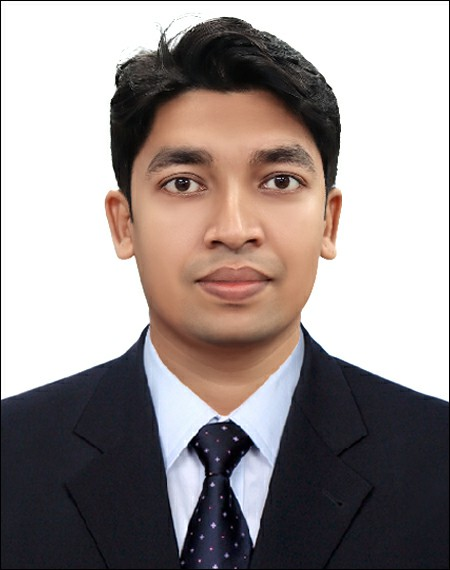

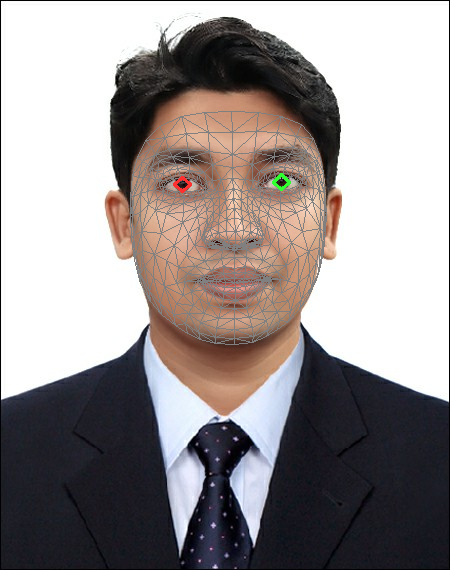

In [ ]:
from google.colab.patches import cv2_imshow

path_img='/content/Shazim uddin pp image with stroke.jpg'
img=cv2.imread(path_img)
annotated_image=img.copy()
result,landmark=get_landmark(image=img)
annotated_image=draw_landmarks(image=annotated_image,result=result)

cv2_imshow(img)
cv2_imshow(annotated_image)
cv2.waitKey(0)
cv2.destroyAllWindows()
# img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
# cv2_imshow(img)